# Task 2.1 — Neural Network in PyTorch
**Week 2 | Skillset Go EduTech AI/ML Track**

A feed-forward neural network in PyTorch covering **tensors, datasets, dataloaders, and loss functions**.
The network is trained on `breast_cancer_cleaned.csv` — the cleaned dataset produced in Week 1 (Task 1.2) —
so it can be compared directly with the Week 1 Logistic Regression baseline.

## 1. Tensor basics

In [1]:
import numpy as np, pandas as pd, torch, torch.nn as nn, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

torch.manual_seed(42); np.random.seed(42)

a = torch.tensor([[1., 2., 3.], [4., 5., 6.]])
b = torch.ones(3, 2)
print("shape:", a.shape, "| dtype:", a.dtype)
print("matmul a @ b =\n", a @ b)
print("mean over dim 0:", a.mean(dim=0))

# Autograd: y = w*x^2 -> dy/dw = x^2
w = torch.tensor(3.0, requires_grad=True)
x = torch.tensor(2.0)
y = w * x**2
y.backward()
print("dy/dw (autograd) =", w.grad.item(), "(expected x^2 = 4.0)")

shape: torch.Size([2, 3]) | dtype: torch.float32
matmul a @ b =
 tensor([[ 6.,  6.],
        [15., 15.]])
mean over dim 0: tensor([2.5000, 3.5000, 4.5000])
dy/dw (autograd) = 4.0 (expected x^2 = 4.0)


## 2. Custom `Dataset` and `DataLoader`

In [2]:
df = pd.read_csv('breast_cancer_cleaned.csv')
X = df.drop(columns=['diagnosis']).values.astype('float32')
y = df['diagnosis'].map({'malignant': 0, 'benign': 1}).values.astype('float32')

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

scaler = StandardScaler().fit(X_tr)          # fit on train only -> no leakage
X_tr, X_val, X_te = [scaler.transform(a).astype('float32') for a in (X_tr, X_val, X_te)]

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = torch.from_numpy(X), torch.from_numpy(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(TabularDataset(X_tr, y_tr), batch_size=32, shuffle=True)
val_loader   = DataLoader(TabularDataset(X_val, y_val), batch_size=64)
test_loader  = DataLoader(TabularDataset(X_te, y_te), batch_size=64)
print(f"train={len(X_tr)}  val={len(X_val)}  test={len(X_te)}  features={X_tr.shape[1]}")
xb, yb = next(iter(train_loader))
print("one batch ->", xb.shape, yb.shape)

train=398  val=85  test=86  features=30
one batch -> torch.Size([32, 30]) torch.Size([32])


## 3. Model, loss function, optimizer

In [3]:
class FeedForwardNet(nn.Module):
    def __init__(self, n_in, hidden=(64, 32), p_drop=0.2):
        super().__init__()
        layers, prev = [], n_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(p_drop)]
            prev = h
        layers.append(nn.Linear(prev, 1))     # raw logit
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)

model = FeedForwardNet(X_tr.shape[1])
criterion = nn.BCEWithLogitsLoss()             # sigmoid + binary cross-entropy (numerically stable)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
trainable parameters: 4097


## 4. Training loop

In [4]:
def run_epoch(loader, train):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            loss_sum += loss.item() * len(yb)
            correct += ((logits > 0).float() == yb).sum().item()
            total += len(yb)
    return loss_sum / total, correct / total

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(1, 41):
    tl, ta = run_epoch(train_loader, True)
    vl, va = run_epoch(val_loader, False)
    for k, v in zip(history, (tl, vl, ta, va)):
        history[k].append(v)
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:2d} | train loss {tl:.4f} acc {ta:.3f} | val loss {vl:.4f} acc {va:.3f}")

epoch  1 | train loss 0.6473 acc 0.761 | val loss 0.5802 acc 0.953
epoch  5 | train loss 0.1477 acc 0.960 | val loss 0.1157 acc 0.965
epoch 10 | train loss 0.0675 acc 0.982 | val loss 0.0518 acc 0.988
epoch 15 | train loss 0.0496 acc 0.990 | val loss 0.0365 acc 0.988


epoch 20 | train loss 0.0380 acc 0.990 | val loss 0.0336 acc 0.976
epoch 25 | train loss 0.0328 acc 0.992 | val loss 0.0319 acc 0.988
epoch 30 | train loss 0.0263 acc 0.992 | val loss 0.0316 acc 0.988
epoch 35 | train loss 0.0235 acc 0.992 | val loss 0.0298 acc 0.988


epoch 40 | train loss 0.0200 acc 0.990 | val loss 0.0340 acc 0.988


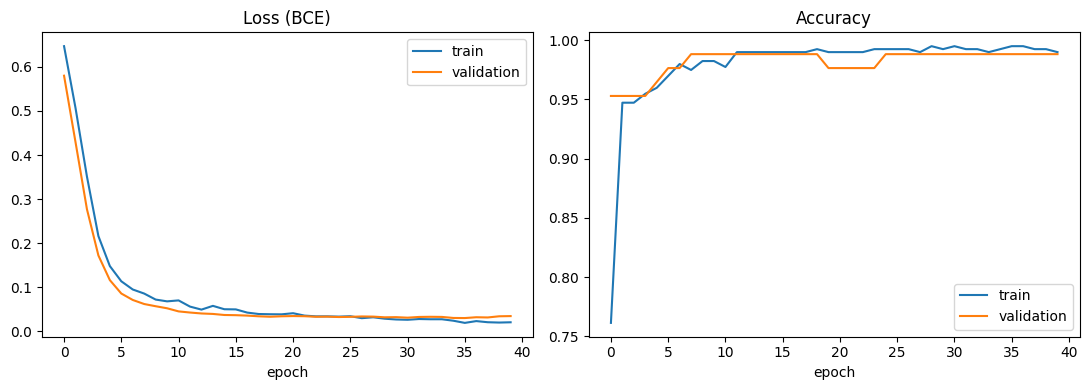

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history['train_loss'], label='train'); ax[0].plot(history['val_loss'], label='validation')
ax[0].set_title('Loss (BCE)'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(history['train_acc'], label='train'); ax[1].plot(history['val_acc'], label='validation')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.savefig('nn_training_curves.png', dpi=110); plt.show()

## 5. Test-set evaluation

In [6]:
model.eval()
with torch.no_grad():
    preds = torch.cat([(model(xb) > 0).float() for xb, _ in test_loader]).numpy()
print("PyTorch feed-forward network — test set")
print(f"  Accuracy  = {accuracy_score(y_te, preds):.4f}")
print(f"  Precision = {precision_score(y_te, preds):.4f}")
print(f"  Recall    = {recall_score(y_te, preds):.4f}")
print(f"  F1-score  = {f1_score(y_te, preds):.4f}")
torch.save(model.state_dict(), 'ffnn_breast_cancer.pt')

PyTorch feed-forward network — test set
  Accuracy  = 0.9535
  Precision = 0.9808
  Recall    = 0.9444
  F1-score  = 0.9623


## Summary
Tensors, autograd, a custom `Dataset`, `DataLoader`s, an `nn.Module`, `BCEWithLogitsLoss`, and a full train/validation loop were implemented. Test accuracy (95.35%) is a few points below the Week 1 logistic regression (98.25%), but the two used different splits and small test sets (86 vs 114 samples), so the gap is only a few samples and is not conclusive. This dataset is close to linearly separable, so extra depth adds little here; depth pays off on image data, the focus of Task 2.2.